# Comparativa de modelos con `procesed.csv`

Este notebook compara los modelos de: Regresión Lineal, Random Forest, Red Neuronal (MLP) y XGBoost para decidir cuál funciona mejor sobre el mismo conjunto de prueba.

## Paso a paso
1. Cargar datos desde `data/procesed.csv`.
2. Definir variable objetivo y separar `X` e `y`.
3. Crear una partición train/test fija para comparar en igualdad.
4. Cargar los modelos `.pkl` entrenados en `models/test/artifacts`.
5. Predecir sobre `X_test` y calcular métricas (MAE, RMSE y R2).
6. Construir un ranking para seleccionar el mejor modelo.
7. Visualizar resultados en gráficos.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, roc_auc_score

RANDOM_STATE = 42
sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
start = Path.cwd().resolve()
project_root = None
for p in [start, *start.parents]:
    if (p / 'pyproject.toml').exists() or (p / 'requirements.txt').exists():
        project_root = p
        break
if project_root is None:
    project_root = start

csv_path = project_root / 'data' / 'procesed.csv'
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontró el archivo esperado: {csv_path}')

df = pd.read_csv(csv_path)
print(f'Archivo: {csv_path}')
print('Shape:', df.shape)
display(df.head())

Archivo: C:\Users\venel\Documents\GitHub\IA0526\PRACTICAML\PRACTICA-MACHINE-LEARNING-limpio\data\procesed.csv
Shape: (86634, 26)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,customer_type,adr,required_car_parking_spaces,total_of_special_requests,has_children,week_sin,week_cos
0,Resort Hotel,0,7,2015,July,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,No Deposit,Transient,75.0,0,0,0,-0.120537,-0.992709
1,Resort Hotel,0,13,2015,July,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,No Deposit,Transient,75.0,0,0,0,-0.120537,-0.992709
2,Resort Hotel,0,14,2015,July,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,No Deposit,Transient,98.0,0,1,0,-0.120537,-0.992709
3,Resort Hotel,0,0,2015,July,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,No Deposit,Transient,107.0,0,0,0,-0.120537,-0.992709
4,Resort Hotel,0,9,2015,July,0,2,2,0.0,0,FB,PRT,Direct,Direct,0,0,0,C,No Deposit,Transient,103.0,0,1,0,-0.120537,-0.992709


In [3]:
TARGET = 'is_canceled'
if TARGET not in df.columns:
    raise ValueError(f'No existe la columna objetivo: {TARGET}')

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

print('Variable objetivo:', TARGET)
print('Distribucion del target:')
display(y.value_counts(normalize=True).rename('ratio'))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Variable objetivo: is_canceled
Distribucion del target:


is_canceled
0    0.72318
1    0.27682
Name: ratio, dtype: float64

Train: (69307, 25) | Test: (17327, 25)


In [4]:
artifacts_dir = project_root / 'models' / 'test' / 'artifacts'
model_files = {
    'Regresion Logistica': artifacts_dir / 'linear_regression_process.pkl',
    'Arbol Decision': artifacts_dir / 'decision_tree_procesed.pkl',
    'Random Forest': artifacts_dir / 'random_forest.pkl',
    'Red Neuronal (MLP)': artifacts_dir / 'red_neuronal.pkl',
    'XGBoost': artifacts_dir / 'xgboost.pkl',
}

missing = [name for name, path in model_files.items() if not path.exists()]
if missing:
    raise FileNotFoundError('Faltan modelos entrenados: ' + ', '.join(missing))

def evaluate_model(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1] if hasattr(model, 'predict_proba') else None
    f1 = f1_score(y_eval, y_pred)
    rec = recall_score(y_eval, y_pred)
    prec = precision_score(y_eval, y_pred)
    acc = accuracy_score(y_eval, y_pred)
    auc = roc_auc_score(y_eval, y_proba) if y_proba is not None else np.nan
    return f1, rec, prec, acc, auc

rows = []
for model_name, model_path in model_files.items():
    model = joblib.load(model_path)
    f1, rec, prec, acc, auc = evaluate_model(model, X_test, y_test)
    rows.append({
        'modelo': model_name,
        'F1': f1,
        'Recall': rec,
        'Precision': prec,
        'Accuracy': acc,
        'ROC_AUC': auc,
        'ruta_modelo': str(model_path)
    })

results_df = pd.DataFrame(rows)
results_df['rank_f1'] = results_df['F1'].rank(method='min', ascending=False)
results_df['rank_recall'] = results_df['Recall'].rank(method='min', ascending=False)
results_df['rank_auc'] = results_df['ROC_AUC'].rank(method='min', ascending=False)
results_df['score_global'] = results_df[['rank_f1', 'rank_recall', 'rank_auc']].mean(axis=1)
results_df = results_df.sort_values('score_global', ascending=True).reset_index(drop=True)

display(results_df[['modelo', 'F1', 'Recall', 'Precision', 'Accuracy', 'ROC_AUC', 'score_global']])

,modelo,F1,Recall,Precision,Accuracy,ROC_AUC,score_global
0,XGBoost,0.674634,0.623853,0.734413,0.833439,0.896564,2.000000
1,Arbol Decision,0.640384,0.889074,0.500411,0.723611,0.864175,2.666667
2,Red Neuronal (MLP),0.663607,0.603003,0.737755,0.830784,0.890709,3.000000
3,Random Forest,0.639778,0.864887,0.507649,0.730421,0.868295,3.000000
4,Regresion Logistica,0.625666,0.771059,0.526406,0.744618,0.834697,4.333333


In [5]:
best_model = results_df.iloc[0]
print('Mejor modelo según ranking global de clasificacion:')
print(f"- Modelo: {best_model['modelo']}")
print(f"- F1: {best_model['F1']:.4f}")
print(f"- Recall: {best_model['Recall']:.4f}")
print(f"- Precision: {best_model['Precision']:.4f}")
print(f"- ROC-AUC: {best_model['ROC_AUC']:.4f}")

Mejor modelo según ranking global de clasificacion:
- Modelo: XGBoost
- F1: 0.6746
- Recall: 0.6239
- Precision: 0.7344
- ROC-AUC: 0.8966


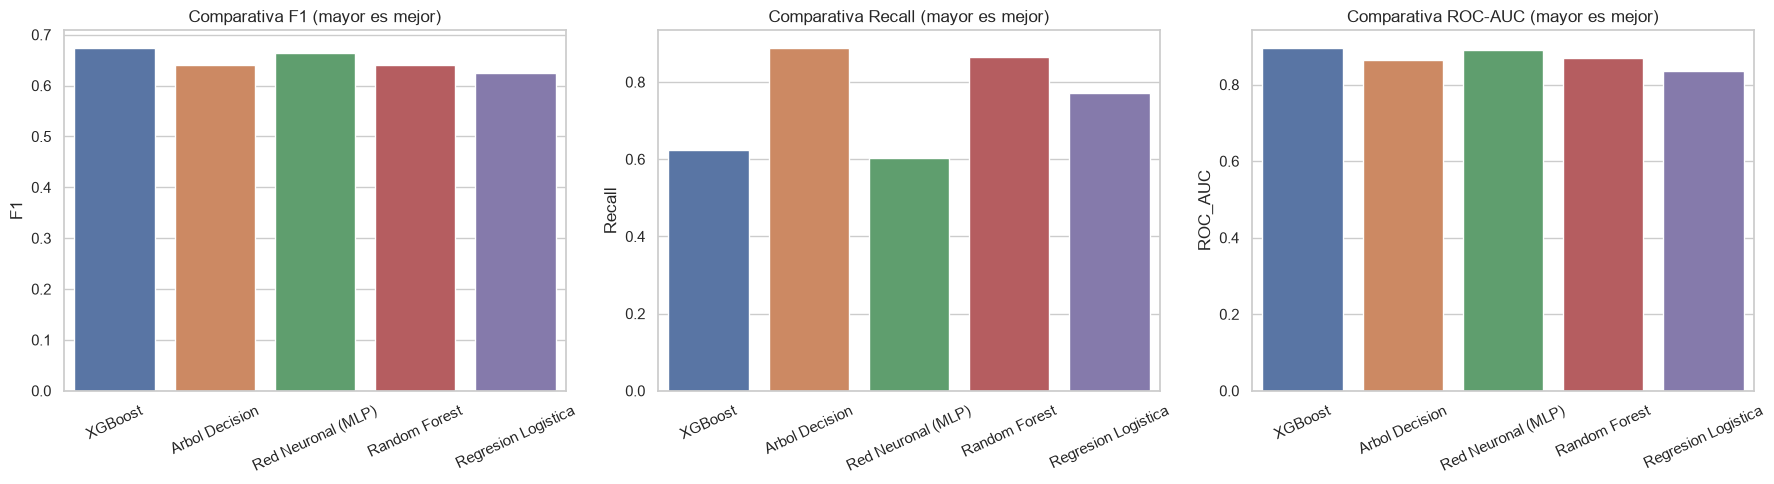

In [6]:
plot_df = results_df.copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=plot_df, x='modelo', y='F1', ax=axes[0], hue='modelo', legend=False)
axes[0].set_title('Comparativa F1 (mayor es mejor)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=plot_df, x='modelo', y='Recall', ax=axes[1], hue='modelo', legend=False)
axes[1].set_title('Comparativa Recall (mayor es mejor)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)

sns.barplot(data=plot_df, x='modelo', y='ROC_AUC', ax=axes[2], hue='modelo', legend=False)
axes[2].set_title('Comparativa ROC-AUC (mayor es mejor)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()